# Univariate EDA

Explore each instrument independently using only the first 500 days (the research/train period): return distributions, volatility, distribution shape and selected individual price behaviour.

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import ipywidgets as widgets
import numpy as np
import pandas as pd

pd.set_option('display.float_format', '{:,.4f}'.format)

repo_root = Path.cwd()
if not (repo_root / 'backtester').exists():
    repo_root = repo_root.parent

TRAIN_DAYS = 500
prices_full = pd.read_csv(repo_root / 'backtester' / 'data' / '2026' / 'prices.txt', sep=r'\s+')
prices = prices_full.iloc[:TRAIN_DAYS].copy()
assert len(prices_full) >= TRAIN_DAYS, 'Not enough observations for the train period'
returns = prices.pct_change(fill_method=None)
normalized_prices = prices.div(prices.iloc[0]).mul(100)

## Return distributions
Use the selector to inspect every instrument individually.

**Flagged instruments**

The table identifies a small starting set for closer visual inspection
* ALGO as the benchmark
* The most volatile stocks
* The strongest and weakest ending price paths

Not a trading recommendation or a complete ranking of the universe.

In [39]:
daily_volatility_pct = returns.std().mul(100).sort_values(ascending=False)
ending_levels = normalized_prices.iloc[-1]

# Edit this list if you want to study specific tickers.
selected_stocks = list(dict.fromkeys([
    'ALGO',
    *daily_volatility_pct.head(3).index,
    ending_levels.idxmax(),
    ending_levels.idxmin(),
]))
flagged_reasons = {'ALGO': ['Benchmark instrument']}
for ticker in daily_volatility_pct.head(3).index:
    flagged_reasons.setdefault(ticker, []).append('Top-three daily volatility')
flagged_reasons.setdefault(ending_levels.idxmax(), []).append('Highest ending normalized price')
flagged_reasons.setdefault(ending_levels.idxmin(), []).append('Lowest ending normalized price')

flagged_stocks = pd.DataFrame({
    'reason': {ticker: '; '.join(reasons) for ticker, reasons in flagged_reasons.items()},
    'daily_volatility_pct': daily_volatility_pct,
    'ending_normalized_price': ending_levels,
}).loc[selected_stocks]

display(flagged_stocks.style.format({
    'daily_volatility_pct': '{:.2f}%',
    'ending_normalized_price': '{:.1f}',
}))

,reason,daily_volatility_pct,ending_normalized_price
ALGO,Benchmark instrument,1.03%,91.8
MMBT,Top-three daily volatility; Highest ending normalized price,4.13%,418.1
AETS,Top-three daily volatility,3.36%,58.9
EELT,Top-three daily volatility,3.35%,115.2
SPLZ,Lowest ending normalized price,2.53%,40.4


In [40]:
def plot_return_distribution(ticker):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(returns[ticker].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set(
        title=f'{ticker}: distribution of daily simple returns',
        xlabel='Daily simple return',
        ylabel='Count',
    )
    plt.show()

ticker_selector = widgets.Dropdown(
    options=sorted(prices.columns),
    value='ALGO',
    description='Ticker:',
)
widgets.interact(plot_return_distribution, ticker=ticker_selector);

interactive(children=(Dropdown(description='Ticker:', index=5, options=('ACAC', 'ACIX', 'AENO', 'AETS', 'AGVF'…

## Volatility

Daily volatility is the standard deviation of daily simple returns. Annualised volatility uses $\sqrt{250}$.

,daily_volatility_pct,annualised_volatility_pct
MMBT,4.1313,65.3212
AETS,3.3574,53.0847
EELT,3.3508,52.9810
RCRI,3.3250,52.5727
NAYO,3.2578,51.5104
RTTH,3.2302,51.0732
CTGI,3.0174,47.7095
ULXY,2.9447,46.5591
HRND,2.9396,46.4795
AMRP,2.7595,43.6312


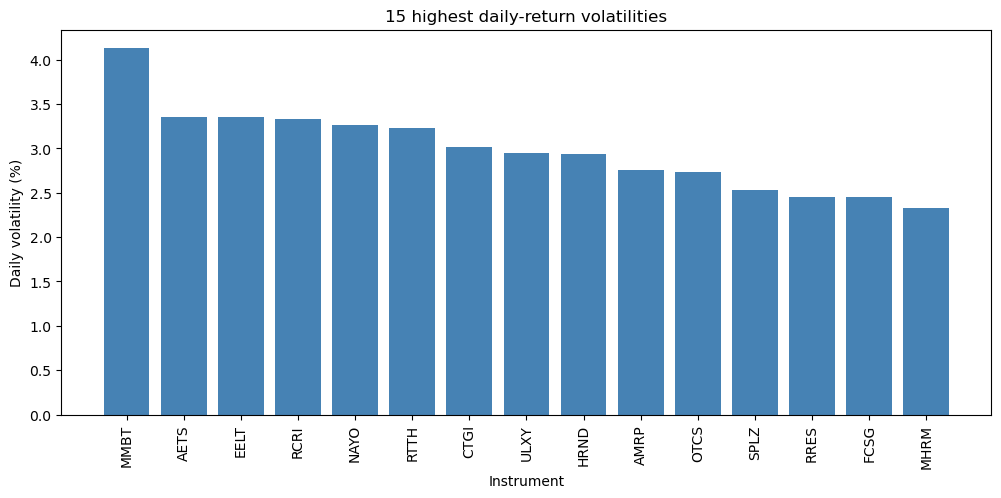

In [41]:
volatility_summary = pd.DataFrame({
    'daily_volatility_pct': returns.std().mul(100),
    'annualised_volatility_pct': returns.std().mul(np.sqrt(250) * 100),
}).sort_values('daily_volatility_pct', ascending=False)

display(volatility_summary)

top_volatility = volatility_summary.head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_volatility.index, top_volatility['daily_volatility_pct'], color='steelblue')
ax.set(title='15 highest daily-return volatilities', xlabel='Instrument', ylabel='Daily volatility (%)')
ax.tick_params(axis='x', rotation=90)
plt.show()

**Notes / interpretation**

- MMBT has the highest train-period daily-return volatility (4.11%); the top-15 range falls to 2.41% at SPLZ.
- ALGO is much less volatile at 0.99%, so these high-volatility instruments are likely to contribute more to portfolio risk and extreme daily PnL.

## Skewness and kurtosis

Skewness measures asymmetry. Kurtosis below is excess kurtosis: a normal distribution is approximately zero.

,skewness,excess_kurtosis,daily_volatility_pct
DUCT,0.2506,0.6068,2.0773
NWIG,0.1812,0.4390,2.1542
AENO,-0.0605,0.3157,1.8236
ANSO,-0.0627,0.2758,2.0568
SRTX,0.0912,0.1782,2.0479
ULXY,0.1015,0.1639,2.9447
CCNS,0.1914,0.1626,2.2214
FARS,0.0805,0.1610,1.5496
AMRP,0.0087,0.1271,2.7595
BENI,-0.1227,0.1227,1.1252


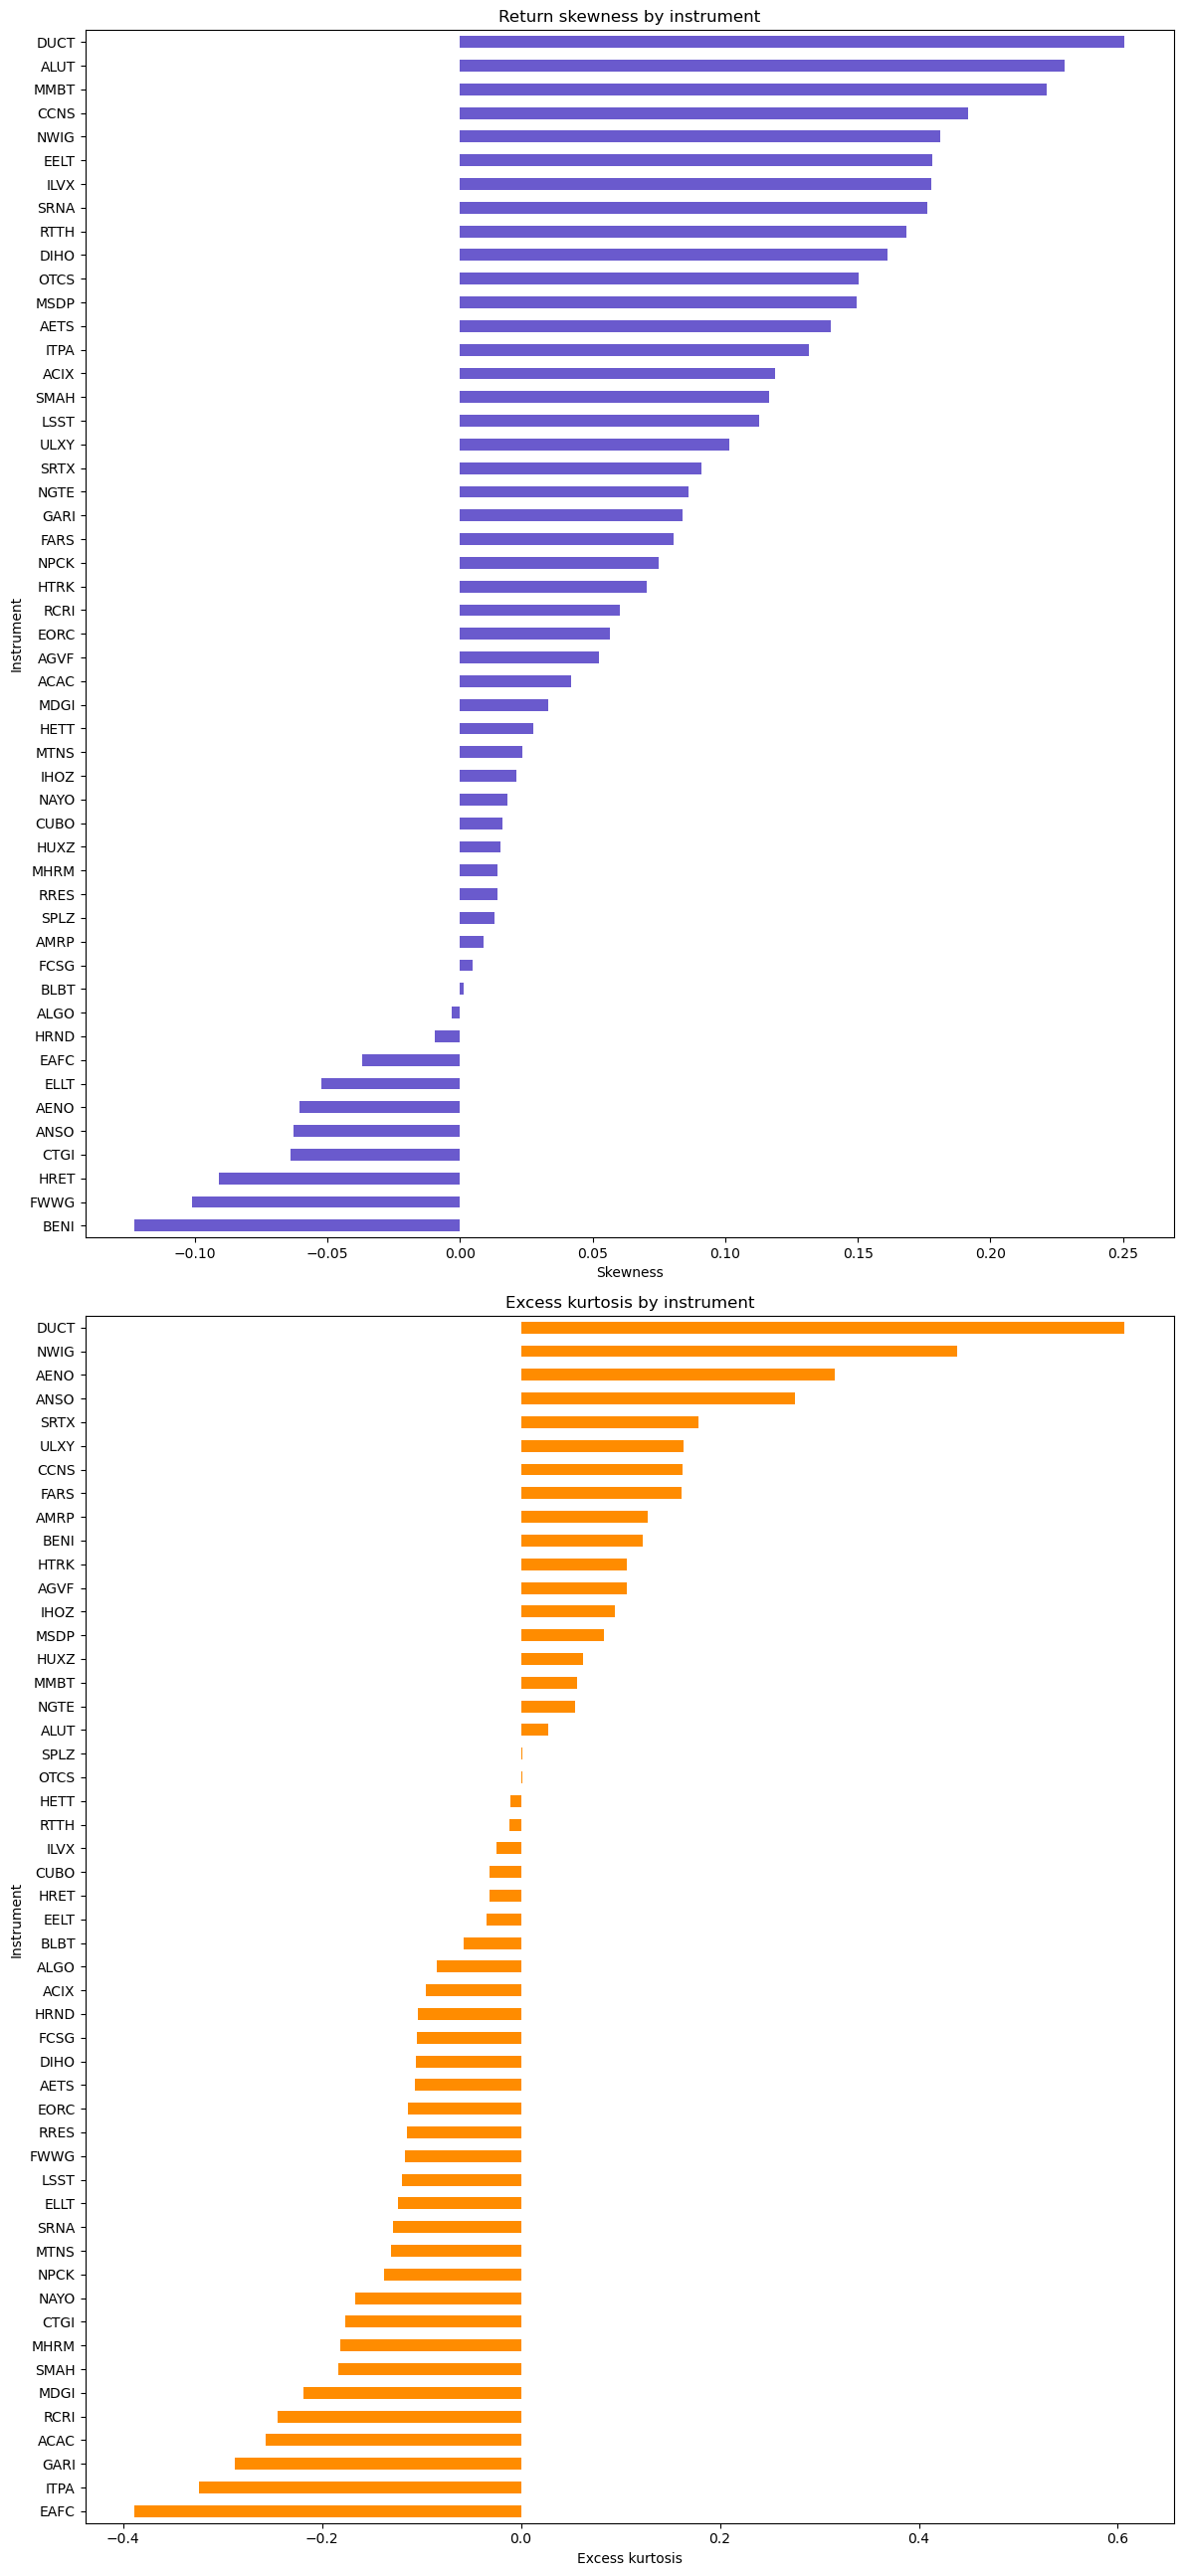

In [42]:
shape_summary = pd.DataFrame({
    'skewness': returns.skew(),
    'excess_kurtosis': returns.kurt(),
    'daily_volatility_pct': returns.std().mul(100),
}).sort_values('excess_kurtosis', ascending=False)

display(shape_summary)

fig, axes = plt.subplots(2, 1, figsize=(12, 26))
shape_summary['skewness'].sort_values().plot.barh(ax=axes[0], color='slateblue')
axes[0].set(title='Return skewness by instrument', xlabel='Skewness', ylabel='Instrument')
shape_summary['excess_kurtosis'].sort_values().plot.barh(ax=axes[1], color='darkorange')
axes[1].set(title='Excess kurtosis by instrument', xlabel='Excess kurtosis', ylabel='Instrument')
plt.tight_layout()
plt.show()

**Notes / interpretation**

- Skewness is modest across the train universe: CCNS is the most positively skewed (0.29), while HRET is the most negatively skewed (-0.17).
- DUCT (0.59), AENO (0.53), and ANSO (0.51) have the highest excess kurtosis. ALGO is close to symmetric with slightly negative excess kurtosis.

## Individual stock behaviour

The left chart shows the normalized price path; the right chart shows daily returns for the same selected instruments. The subset includes ALGO as a benchmark, the three most volatile instruments, and the strongest and weakest ending price paths so that contrasting behaviour can be compared without plotting all 51 instruments at once.

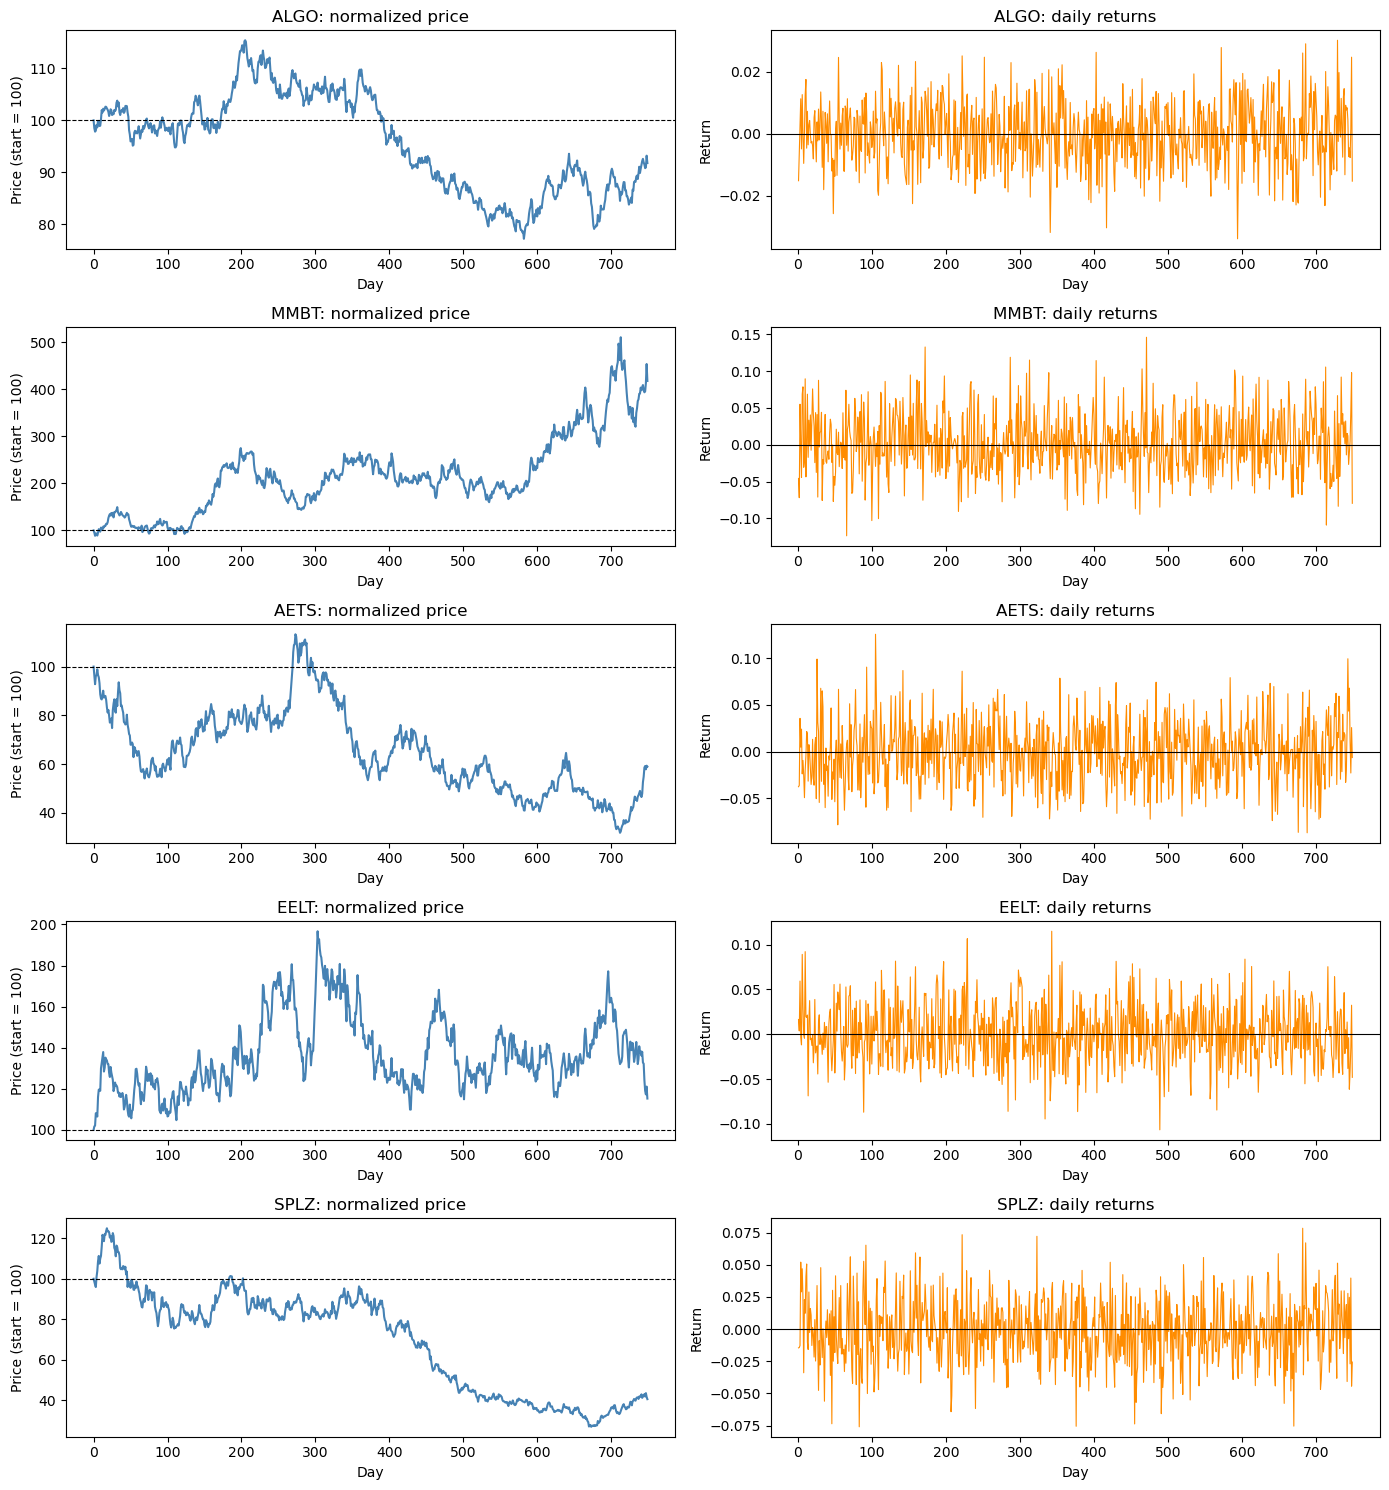

In [43]:
fig, axes = plt.subplots(len(selected_stocks), 2, figsize=(14, 3 * len(selected_stocks)))
axes = np.atleast_2d(axes)

for row, ticker in zip(axes, selected_stocks):
    row[0].plot(normalized_prices[ticker], color='steelblue')
    row[0].axhline(100, color='black', linewidth=0.8, linestyle='--')
    row[0].set(title=f'{ticker}: normalized price', xlabel='Day', ylabel='Price (start = 100)')

    row[1].plot(returns[ticker], color='darkorange', linewidth=0.8)
    row[1].axhline(0, color='black', linewidth=0.8)
    row[1].set(title=f'{ticker}: daily returns', xlabel='Day', ylabel='Return')

plt.tight_layout()
plt.show()

## Rolling volatility, drawdowns, and return autocorrelation

These time-series diagnostics use the flagged instruments. Rolling volatility shows how risk changes over time; drawdown measures decline from a prior peak; lag-1 autocorrelation measures the relationship between consecutive daily returns.

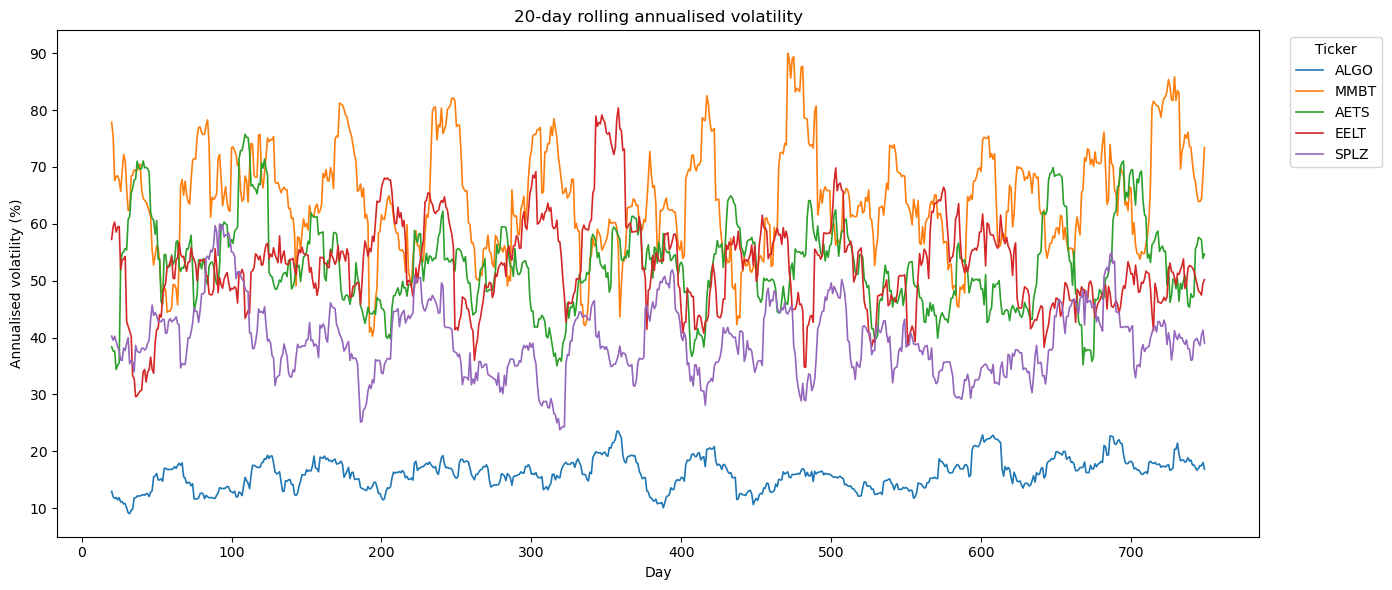

In [44]:
rolling_window = 20
rolling_volatility_pct = returns[selected_stocks].rolling(rolling_window).std().mul(np.sqrt(250) * 100)

fig, ax = plt.subplots(figsize=(14, 6))
rolling_volatility_pct.plot(ax=ax, linewidth=1.2)
ax.set(
    title=f'{rolling_window}-day rolling annualised volatility',
    xlabel='Day',
    ylabel='Annualised volatility (%)',
)
ax.legend(title='Ticker', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

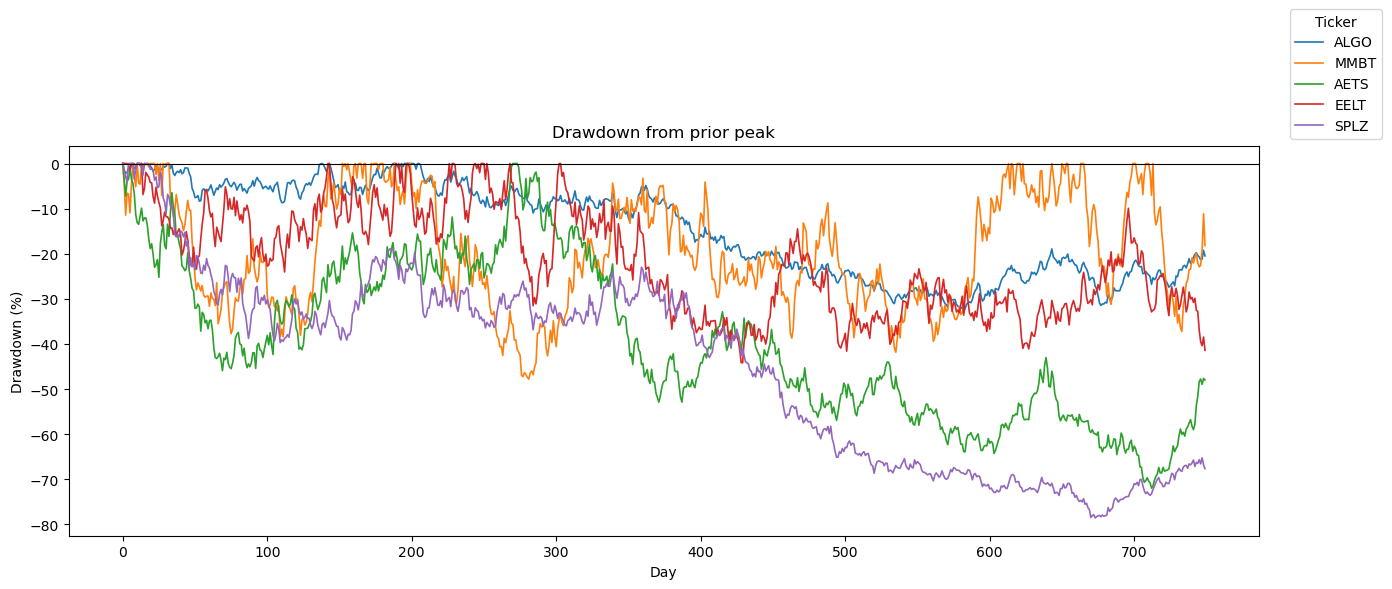

In [45]:
drawdowns_pct = normalized_prices[selected_stocks].div(
    normalized_prices[selected_stocks].cummax()
).sub(1).mul(100)

fig, ax = plt.subplots(figsize=(14, 6))
drawdowns_pct.plot(ax=ax, linewidth=1.2)
ax.set(title='Drawdown from prior peak', xlabel='Day', ylabel='Drawdown (%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title='Ticker', bbox_to_anchor=(1.02, 1), loc='lower left')
plt.tight_layout()
plt.show()

In [46]:
lag_1_autocorrelation = returns.corrwith(returns.shift(1)).rename('lag_1_autocorrelation')
selected_autocorrelation = lag_1_autocorrelation.loc[selected_stocks].to_frame()

display(selected_autocorrelation.style.format('{:+.3f}'))

,lag_1_autocorrelation
ALGO,+0.020
MMBT,+0.008
AETS,-0.001
EELT,-0.011
SPLZ,-0.025


**Notes / interpretation**

- The high-volatility flagged stocks have much larger drawdowns than ALGO: EAFC reaches 63.1% and RCRI reaches 56.4%, versus ALGO at 26.5%.
- Within this flagged subset, lag-1 autocorrelations are close to zero (-0.023 to +0.068), so this simple diagnostic finds no clear one-day continuation or reversal signal for these instruments.
- This is not a universe-wide conclusion: rank autocorrelation across all 51 instruments and test any candidate effect in rolling or out-of-sample windows.

## Summary of findings
**Findings**
- Individual price paths and volatility differ substantially across the train universe; MMBT is the most volatile (4.11% daily), while ALGO is comparatively stable (0.99%).
- Return-shape differences are modest overall, but DUCT, AENO, and ANSO have the highest excess kurtosis and are worth monitoring for relatively extreme moves.
- The high-volatility flagged stocks also show much larger drawdowns than ALGO; within this subset, lag-1 return autocorrelations are near zero.

**Implications**
* High-volatility names such as MMBT, EELT, and RCRI can create large PnL swings and drawdowns. 
* ALGO is comparatively stable, so it is useful as a benchmark or potential hedge/reference series, not necessarily as the main source of volatility-driven returns.
* Within the flagged subset, near-zero lag-1 autocorrelation does not support a naïve one-day momentum or reversal rule. Test the full universe before generalising.
* Different price paths, volatility levels and distribution shapes suggest the next useful research is relationships between instruments: correlations, lead-lag effects, cross-sectional forecasts and potential pairs.
* DUCT, AENO, and ANSO’s higher kurtosis mean their extreme moves should be considered when testing robustness; do not let a small number of outlier days create a misleading backtest result.